In [27]:
import pandas as pd
import numpy as np
import joblib
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [28]:
#load the cleaned data
df = pd.read_csv('D:/downloads 2 imp/2ND TERM 3RD YEAR/Intelligent Programming/MAIN PROJECT/Data Cleaning/heart_Cleaned data.csv')

In [29]:
#Define The Input Features X And Target y
#Ensure target is removed from features
X = df.drop(columns=['target'])
y = df['target']
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [30]:
#Train the Decision Tree
classifier = DecisionTreeClassifier(max_depth=3, random_state=42)
classifier.fit(X, y)
# saves your trained logic into a .joblib file
joblib.dump(classifier, 'D:/downloads 2 imp/2ND TERM 3RD YEAR/Intelligent Programming/MAIN PROJECT/Decison Tree (Model Train)/heart_disease_model.joblib')

['D:/downloads 2 imp/2ND TERM 3RD YEAR/Intelligent Programming/MAIN PROJECT/Decison Tree (Model Train)/heart_disease_model.joblib']

Accuracy:  0.89
Precision: 0.90
Recall:    0.88
F1 Score:  0.89
Classification Report 
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       144
           1       0.90      0.88      0.89       146

    accuracy                           0.89       290
   macro avg       0.89      0.89      0.89       290
weighted avg       0.89      0.89      0.89       290



Text(0.5, 1.0, 'Confusion Matrix - Heart Disease Prediction')

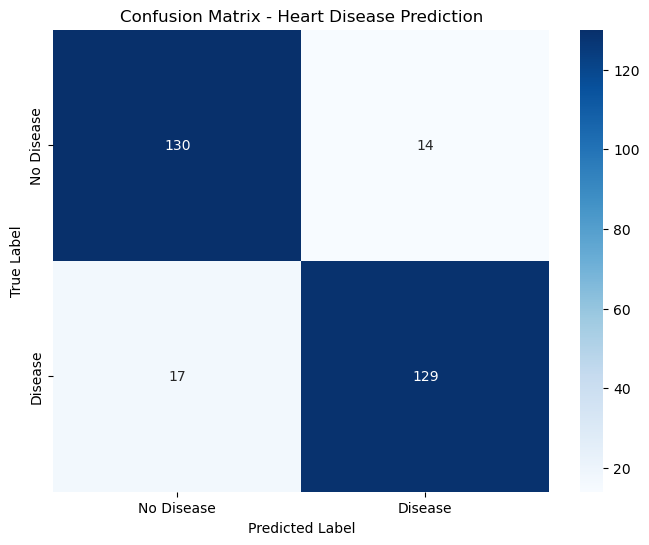

In [31]:
#Evaluate the Model
y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1_Score = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1_Score :.2f}")

print("Classification Report ")
print(classification_report(y_test, y_pred))

#Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Heart Disease Prediction')

In [32]:
#Defining a "New Patient" to test the model using the dictionary note that all the values are scaled using the Min-Max Scalling
new_patient_data = {
    'oldpeak': [0.238095238095238],
    'exang': [0],
    'thalach': [0.701754385964912],
    'cp': [0],
    'ca': [2],
    'thal': [3],
    'slope': [2],
    'sex': [1],
    'age': [0.479166666666666],
    'restecg': [1.0],
    'chol': [0.367521367521367],
    'trestbps': [0.407894736842105]
}

#Convert dictionary to DataFrame (the model expects a 2D structure)
new_patient_df = pd.DataFrame(new_patient_data)
new_patient_df

,oldpeak,exang,thalach,cp,ca,thal,slope,sex,age,restecg,chol,trestbps
0,0.238095,0,0.701754,0,2,3,2,1,0.479167,1.0,0.367521,0.407895


In [33]:
#Perform the Prediction
prediction = classifier.predict(new_patient_df)
#Output results
result = "Heart Disease" if prediction[0] == 1 else "No Heart Disease"
print(f"Prediction: {result}")

Prediction: No Heart Disease


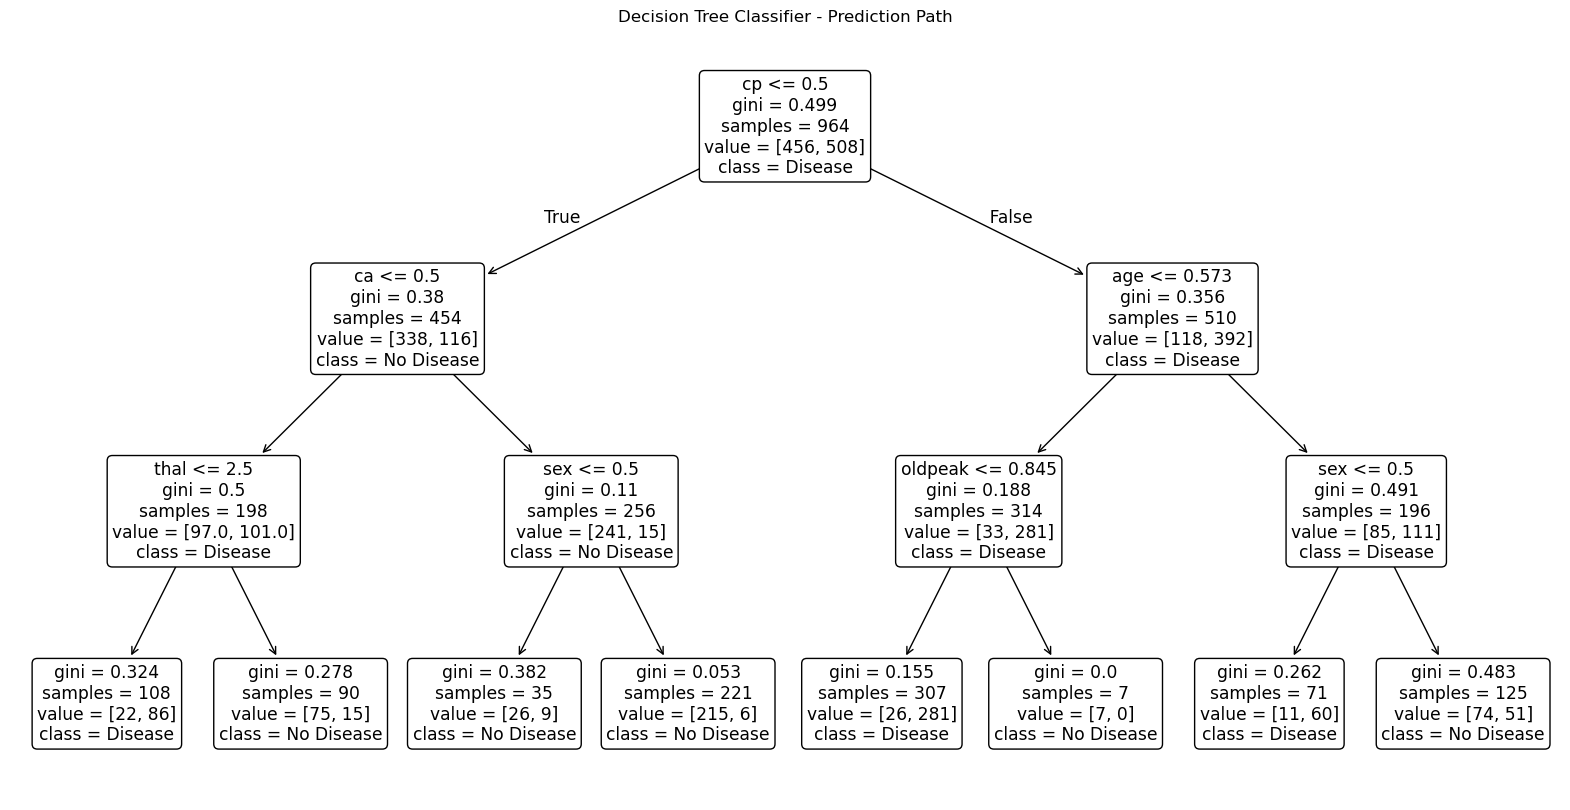

In [34]:
# Visualizing the Tree
plt.figure(figsize=(20, 10))
plot_tree(classifier, feature_names=X.columns.tolist(), class_names=['No Disease', 'Disease'], rounded=True)
plt.title("Decision Tree Classifier - Prediction Path")
plt.show()